# Final Project Notebook

## Client: Maple Bank

Problem (Taken from Client Proposal):

Over the years, Maple Bank has experienced an increase in fraudulent credit card
transactions. This has led to higher financial losses and more customer complaints.
The Maple fraud team and management are currently considering three possible ways
to respond:

    ● Option A: Hire more fraud analysts and increase manual review.
    ● Option B: Detect fraud using simple transaction rules such as transaction amount or location.
    ● Option C: Develop a model that predicts whether a transaction is fraudulent or not based on numerous transaction characteristics.


The Task:

    ● Phase 1:
        ○ Conduct exploratory data analysis to examine and identify characteristics of legitimate and fraudulent transactions. 
        From your analysis, determine which of the three options the Maple Bank fraud team and their management should pursue? Justify
        your recommendation based on your analysis.
    ● Phase 2:
        ○ Assuming that Maple management chooses Option C, identify which variables are most useful for fraud detection, what type of 
        machine learning model would be best suited for the task and why, and what evaluation metrics would be important.

Essentially, Phase 1 states that we need to find ways we can ***PREDICT*** that a transaction is fraudulent.
Phase 2 states that if we need to develop a model that determines if a transaction is fradulent or not, how would we do it?

In [181]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [182]:
df = pd.read_csv('/Users/cross/Desktop/sfu_2/IAT461/final_project/fraud_detection_credit_card_small.csv', index_col=0)

In [183]:
#Let's be able to see every column.
pd.set_option('display.max_columns', None)

In [184]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372


Hmmm, can't get rid of that "Unnamed: 0" column even with index_col=0. Look into this.

In [185]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 1045211 to 1049499
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   trans_date_trans_time        100000 non-null  str    
 1   cc_num                       100000 non-null  int64  
 2   merchant                     100000 non-null  str    
 3   category                     100000 non-null  str    
 4   amt                          100000 non-null  float64
 5   first                        100000 non-null  str    
 6   last                         100000 non-null  str    
 7   gender                       100000 non-null  str    
 8   street                       100000 non-null  str    
 9   city                         100000 non-null  str    
 10  state                        100000 non-null  str    
 11  zip                          100000 non-null  int64  
 12  lat                          100000 non-null  float64
 13  long    

In [186]:
df.isnull().sum()

trans_date_trans_time              0
cc_num                             0
merchant                           0
category                           0
amt                                0
first                              0
last                               0
gender                             0
street                             0
city                               0
state                              0
zip                                0
lat                                0
long                               0
city_pop                           0
job                                0
dob                                0
trans_num                          0
unix_time                          0
merch_lat                          0
merch_long                         0
is_fraud                           0
merch_zipcode                  15176
Merchant_Category                  0
Transaction_Type                   0
Customer_Satisfaction_Score        0
Transaction_Time                   0
C

#### That's a lot of missing values, and I'd like to consider removing those, but as mentioned in https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/ what if that introduces further, major bias due to missingness being very random? 

#### I'm going to split df.info into two datasets, one with fraud and one without fraud, and compare missingness in both.

In [187]:
df_not_fraud = df[df["is_fraud"] == 0]
df_fraud = df[df["is_fraud"] == 1]

In [189]:
df_fraud.info()

<class 'pandas.DataFrame'>
Index: 598 entries, 307415 to 491091
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trans_date_trans_time        598 non-null    str    
 1   cc_num                       598 non-null    int64  
 2   merchant                     598 non-null    str    
 3   category                     598 non-null    str    
 4   amt                          598 non-null    float64
 5   first                        598 non-null    str    
 6   last                         598 non-null    str    
 7   gender                       598 non-null    str    
 8   street                       598 non-null    str    
 9   city                         598 non-null    str    
 10  state                        598 non-null    str    
 11  zip                          598 non-null    int64  
 12  lat                          598 non-null    float64
 13  long                        

In [190]:
# Calculate percentage of fraud transactions with merch_zipcodes missing compared to all fraud transactions
((598-512)/598) * 100

14.381270903010032

Only 14% of fraud transactions are missing merch_zipcodes, which doesn't seem like a lot. What about non-fraud?

In [191]:
df_not_fraud.info()

<class 'pandas.DataFrame'>
Index: 99402 entries, 1045211 to 1049499
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trans_date_trans_time        99402 non-null  str    
 1   cc_num                       99402 non-null  int64  
 2   merchant                     99402 non-null  str    
 3   category                     99402 non-null  str    
 4   amt                          99402 non-null  float64
 5   first                        99402 non-null  str    
 6   last                         99402 non-null  str    
 7   gender                       99402 non-null  str    
 8   street                       99402 non-null  str    
 9   city                         99402 non-null  str    
 10  state                        99402 non-null  str    
 11  zip                          99402 non-null  int64  
 12  lat                          99402 non-null  float64
 13  long                    

In [192]:
# Calculate percentage of non-fraud transactions with merch_zipcodes missing compared to all non-fraud transactions
((99402-84312)/99402)*100

15.180781070803404

Only 15% of all non-fraud transactions have missing merch_zipcode values; this is a similar amount to the non-fraud transactions. Based on this, it doesnt seem likely that merch_zipcode values that are missing could be tied to finding fraud.

The only missing values are in merch_zipcode. I will drop those, because in the event that I need to plot something pertaining to those zip codes, it cannot be done, and there is no feasible substitute value for a missing zipcode except NaN. to keep them as they might be useful down the line for determining which transactions are fraudulent.

In [193]:
df = df.dropna()

In [194]:
df.isnull().sum()

trans_date_trans_time          0
cc_num                         0
merchant                       0
category                       0
amt                            0
first                          0
last                           0
gender                         0
street                         0
city                           0
state                          0
zip                            0
lat                            0
long                           0
city_pop                       0
job                            0
dob                            0
trans_num                      0
unix_time                      0
merch_lat                      0
merch_long                     0
is_fraud                       0
merch_zipcode                  0
Merchant_Category              0
Transaction_Type               0
Customer_Satisfaction_Score    0
Transaction_Time               0
Customer_Age                   0
Payment_Method                 0
Loyalty_Points_Earned          0
dtype: int

What about **negative values** in places that wouldn't make sense? Let's try to find any and address those.

The variables that come to mind are: 'Customer_Age', 'amt', 'Customer_Satisfaction_Score', 'Loyalty_Points_Earned'.


I also believe it makes sense to look for transactions with an 'amt' of 0; if no money was spent, then it doesn't make sense for that transaction to have been recorded.

In [195]:
df_negative_numerics = df[(df['amt'] <= 0) | (df['Customer_Age'] <= 0) | (df['Customer_Satisfaction_Score'] < 0) | (df['Loyalty_Points_Earned'] < 0)]
df_negative_numerics 

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


The dataframe is empty, so thankfully there aren't any negative values in these areas for us to clean up.

### That should encompass cleaning, now onto EDA

One major column of focus appears to be is_fraud, because we want to know the best way to detect this, so as already done we've tried splitting our dataset into fraud/non-fraud datasets. Finding notable patterns we can observe by eyeshot within fraudulent/non-fraudulent transactions and compare them to see if the solution is as easy as just getting more manual reviewers to read each case. 

#### OPTION A: More Manual Reviewers?

It looks like we have numeric features such as Customer_Age, amt, Customer_Satisfaction_Score and Loyalty_Points_Earned.

We've also got categorical variables in Transaction_Type, Payment_Method and/or Merchant_Category.

I'd like to try looking into these to see if any could have some correlation with fraud.

### Let's find out some basic things about the patterns of fraud.

#### I wonder if, but eyeshot, we can immediately detect a heavy bias in any of Transaction_Type, Payment_Method and/or Merchant_Category that hints at a particular value in any of those categories could potentially correlate to being classified as fraud or not.

Text(0, 0.5, 'Count')

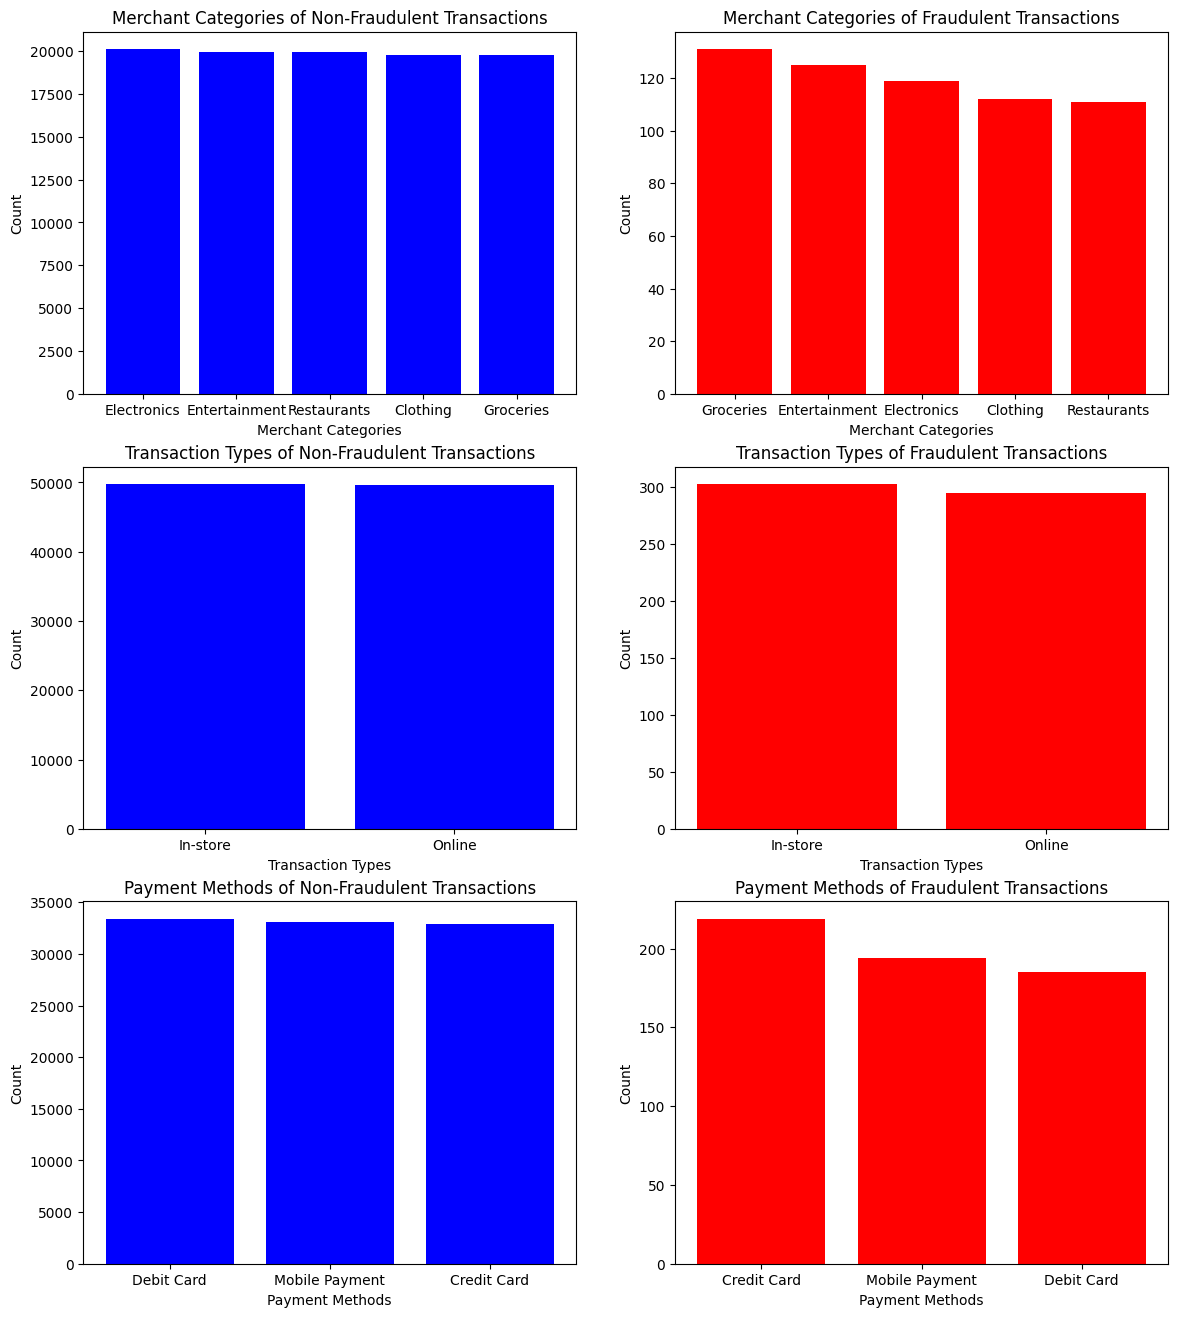

In [205]:
fig, axes = plt.subplots(3, 2, figsize=(14,16))
axes = axes.flatten()

# https://www.geeksforgeeks.org/python/get-unique-values-from-a-column-in-pandas-dataframe/
categories = ['Entertainment', 'Electronics', 'Restaurants', 'Clothing', 'Groceries']
axes[0].bar(df_not_fraud['Merchant_Category'].unique(), df_not_fraud['Merchant_Category'].value_counts(), color='blue')
axes[0].set_title("Merchant Categories of Non-Fraudulent Transactions")
axes[0].set_xlabel('Merchant Categories')
axes[0].set_ylabel('Count')

axes[1].bar(df_fraud['Merchant_Category'].unique(), fraud_merch_count, color='red')
axes[1].set_title("Merchant Categories of Fraudulent Transactions")
axes[1].set_xlabel('Merchant Categories')
axes[1].set_ylabel('Count')

axes[2].bar(df_not_fraud['Transaction_Type'].unique(), df_not_fraud['Transaction_Type'].value_counts(), color='blue')
axes[2].set_title("Transaction Types of Non-Fraudulent Transactions")
axes[2].set_xlabel('Transaction Types')
axes[2].set_ylabel('Count')


axes[3].bar(df_fraud['Transaction_Type'].unique(), df_fraud['Transaction_Type'].value_counts(), color='red')
axes[3].set_title("Transaction Types of Fraudulent Transactions")
axes[3].set_xlabel('Transaction Types')
axes[3].set_ylabel('Count')

axes[4].bar(df_not_fraud['Payment_Method'].unique(), df_not_fraud['Payment_Method'].value_counts(), color='blue')
axes[4].set_title("Payment Methods of Non-Fraudulent Transactions")
axes[4].set_xlabel('Payment Methods')
axes[4].set_ylabel('Count')


axes[5].bar(df_fraud['Payment_Method'].unique(), df_fraud['Payment_Method'].value_counts(), color='red')
axes[5].set_title("Payment Methods of Fraudulent Transactions")
axes[5].set_xlabel('Payment Methods')
axes[5].set_ylabel('Count')

It looks like the category values among all three categories are overall quite balanced, making it hard by eyeshot to determine if a certain value in any of them is a major hint. It implies that getting more manual review on the transactions may not be the most beneficial if the method of review is to pick off transactions by notable shared traits in the past.

It seems, however, that for fraud transactions, more seem to have a **merchant category** of **Groceries** and a **transaction type** of **Credit Card** than other posible values in that category. This could be something to look into with encoding down the line.

#### OPTION B: Detect fraud using simple transaction rules such as transaction amount or location?

#### Let's try getting a boxplot of transaction amounts, as suggested in Option B

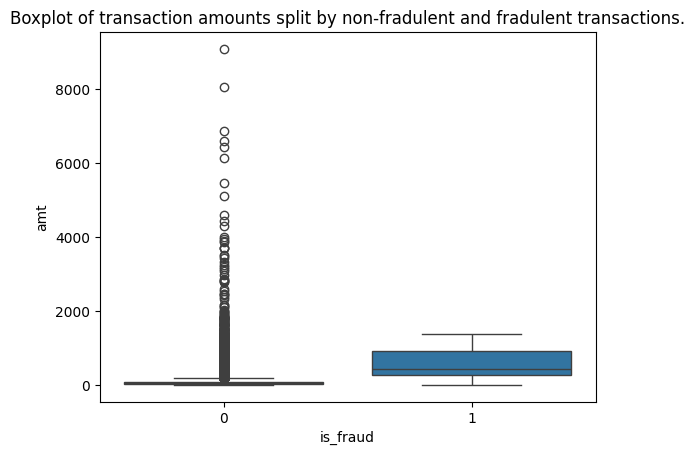

In [206]:
sns.boxplot(x='is_fraud', y='amt', data=df).set(title='Boxplot of transaction amounts split by non-fradulent and fradulent transactions.')
plt.show()

That's a pretty stark difference; there are many outliers in the not-fraud category, but generally speaking the overall monetary amount of non-fraudulent transactions is significantly llower than those of the fraudent type. Granted, the dataset is imbalanced in the sense that many of the transactions in the dataset are not fraudulent. 

Still, given how overwhelmingly different the amount of transactions that are fraud or not, we definitely have to note how no fraudulent transactions go above $2000 in our dataset, but those transactions would tend to be much higher in monetary amount than the average non-fraudulent transaction.

**Therefore, we could guess it it is more likely that that a transaction is below that amount range would be fraud; perhaps, smaller sums of money are favoured in fraudulent transactions so not as to draw attention from fraud detectors.**

Could we double down on confirming the correlation between amt and fraud? Maybe we can try a **correlation matrix.** We can include other numerical features.

In [207]:
numeric_features = [
'Customer_Age', 'amt', 'Customer_Satisfaction_Score', 'Loyalty_Points_Earned', 'is_fraud'
]

In [208]:
df_not_fraud["Merchant_Category"].value_counts()

Merchant_Category
Electronics      20106
Entertainment    19918
Groceries        19913
Restaurants      19735
Clothing         19730
Name: count, dtype: int64

In [209]:
fraud_merchant_category_counts = df_fraud["Merchant_Category"].value_counts()

Simple transaction rules could be gleaned from averages, perhaps.
Could customer age correlate with higher chance of fraud (as people get older, are they more likely to fall into fraud)? Perhaps higher money spent correlates to being involved in fraud?

In [210]:
spearman_corr_matrix = df[numeric_features].corr(method='spearman')
print(spearman_corr_matrix.round(2))

                             Customer_Age   amt  Customer_Satisfaction_Score  \
Customer_Age                          1.0  0.00                         0.00   
amt                                   0.0  1.00                        -0.00   
Customer_Satisfaction_Score           0.0 -0.00                         1.00   
Loyalty_Points_Earned                -0.0 -0.00                        -0.00   
is_fraud                             -0.0  0.09                         0.01   

                             Loyalty_Points_Earned  is_fraud  
Customer_Age                                  -0.0     -0.00  
amt                                           -0.0      0.09  
Customer_Satisfaction_Score                   -0.0      0.01  
Loyalty_Points_Earned                          1.0      0.00  
is_fraud                                       0.0      1.00  


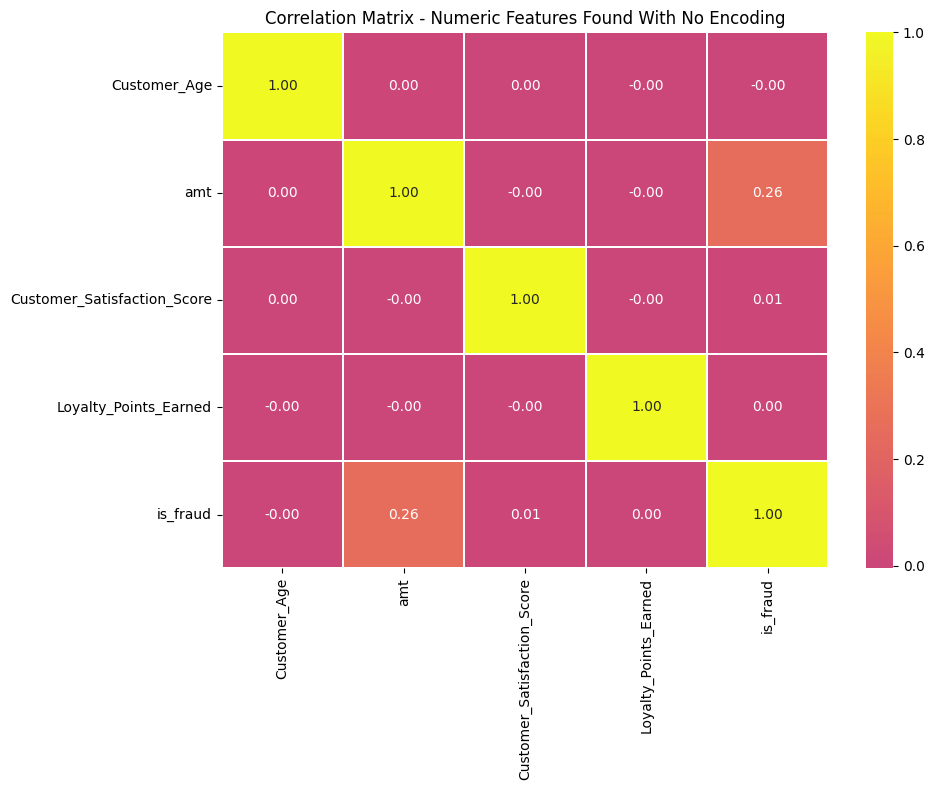

In [211]:
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize = (10, 8))

sns.heatmap (
    corr, 
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center = 0,
    ax = ax,
    linewidths=0.35
)

ax.set_title("Correlation Matrix - Numeric Features Found With No Encoding")
plt.tight_layout()
plt.show()


We can see that the only naturally numerical category that could potentially have a correlation with fraudulent transactions is amt; the amount of a transaction. This lines up with the earlier conclusion drawn from the boxplots, but the correlation isn't strong enough for me to say that this is a very notable sign of fraud.

**Moving forward, I'd like to try label encoding to convert classes in 'Merchant_Category' and 'Payment_Method' to visualize their correlations. Location could also be a potential aspect of transactions to look into for leads.**